# Отчет по линейной регрессии

**Лабораторная работа 1**  
**Дисциплина:** Системы искусственного интеллекта и машинное обучение  
**Тема:** Линейная регрессия и факторный анализ (PCA)  
**Вариант:** Medical Cost Personal Datasets

## 1. Введение

### Цель работы

Изучить основы линейной регрессии на реальном датасете, построить модели прогнозирования медицинских расходов (`charges`), оценить качество моделей и исследовать влияние снижения размерности признаков методом PCA.

### Постановка задачи

В рамках работы необходимо:

1. Провести первичный анализ датасета `insurance`.
2. Выполнить предобработку данных и кодирование категориальных признаков.
3. Оценить взаимосвязи признаков и мультиколлинеарность (корреляции и VIF).
4. Обучить модели линейной и гребневой регрессии на исходных признаках.
5. Оценить качество по метрикам `RMSE`, `R²`, `MAPE` и кросс-валидации.
6. Выполнить стандартизацию и PCA, затем повторить моделирование на главных компонентах.
7. Сравнить результаты до и после PCA и сделать выводы.

### Краткое описание датасета

Датасет **Medical Cost Personal Datasets** содержит признаки о пациентах (возраст, индекс массы тела, наличие детей, курение, регион) и целевую переменную `charges` — индивидуальные медицинские расходы.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import skew, kurtosis, probplot

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [2]:
# Пытаемся загрузить локальный файл, иначе используем публичное зеркало
local_path = Path("../data/insurance.csv")
backup_url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

if local_path.exists():
    df = pd.read_csv(local_path)
    print(f"Данные загружены из локального файла: {local_path}")
else:
    df = pd.read_csv(backup_url)
    print("Локальный файл не найден, данные загружены из публичного зеркала.")

print(f"Размер датасета: {df.shape}")
df.head()

Данные загружены из локального файла: ..\data\insurance.csv
Размер датасета: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Анализ данных

На этом этапе рассматривается структура датасета, типы признаков, наличие пропусков и распределения целевой и входных переменных.

In [3]:
# Общая информация о данных
print("\nИнформация о датасете:")
display(df.info())

print("\nОписательная статистика числовых признаков:")
display(df.describe().T)

print("\nПропущенные значения:")
display(df.isna().sum())


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None


Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801



Пропущенные значения:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

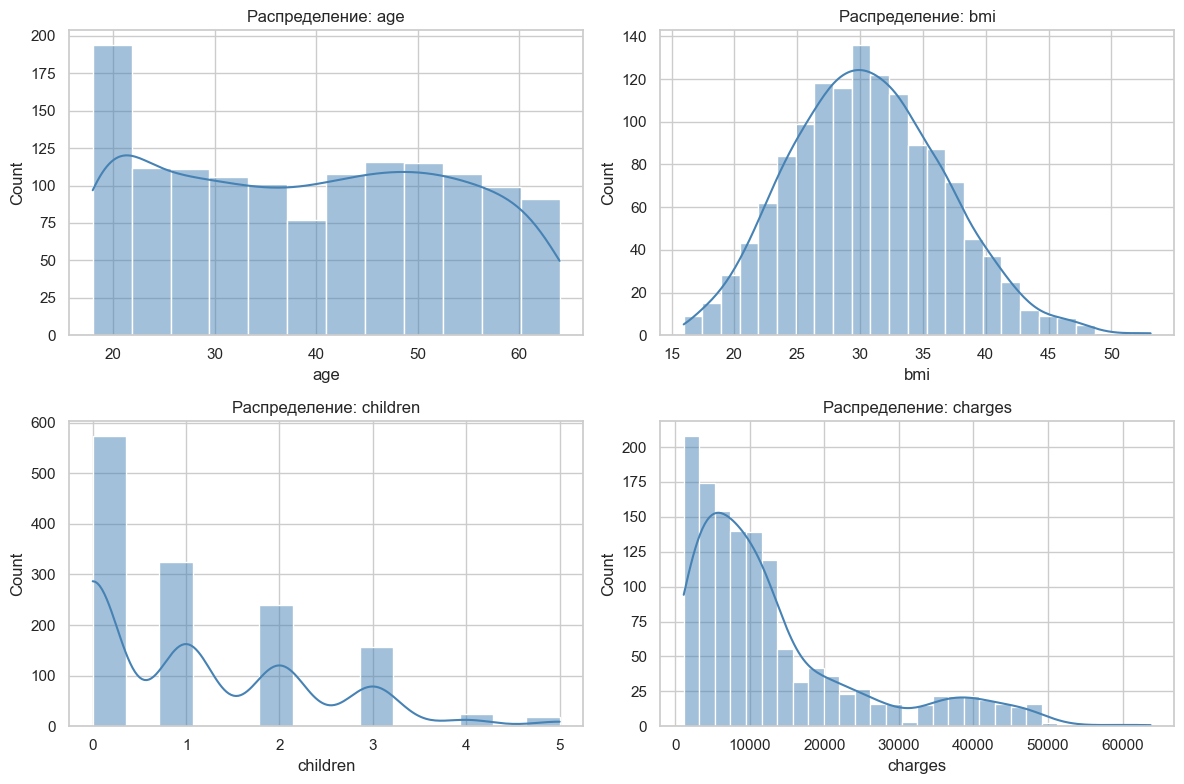

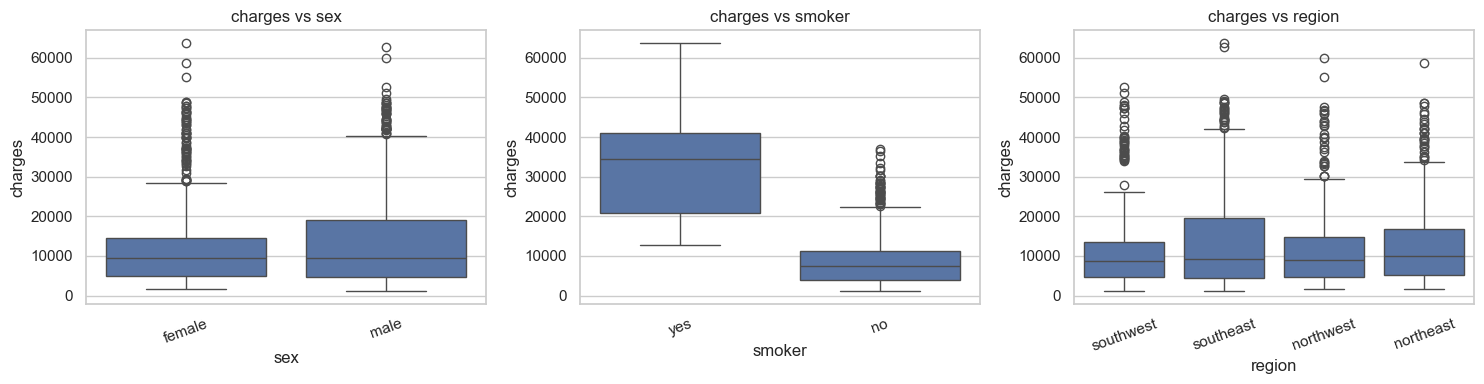

In [4]:
# Распределения числовых признаков и целевой переменной
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Распределение: {col}")

plt.tight_layout()
plt.show()

# Визуализация влияния категориальных признаков на целевую переменную
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=col, y="charges", ax=ax)
    ax.set_title(f"charges vs {col}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

,feature,skewness,kurtosis
0,charges,1.514180,1.595821
1,age,0.055610,-1.244921
2,bmi,0.283729,-0.055023


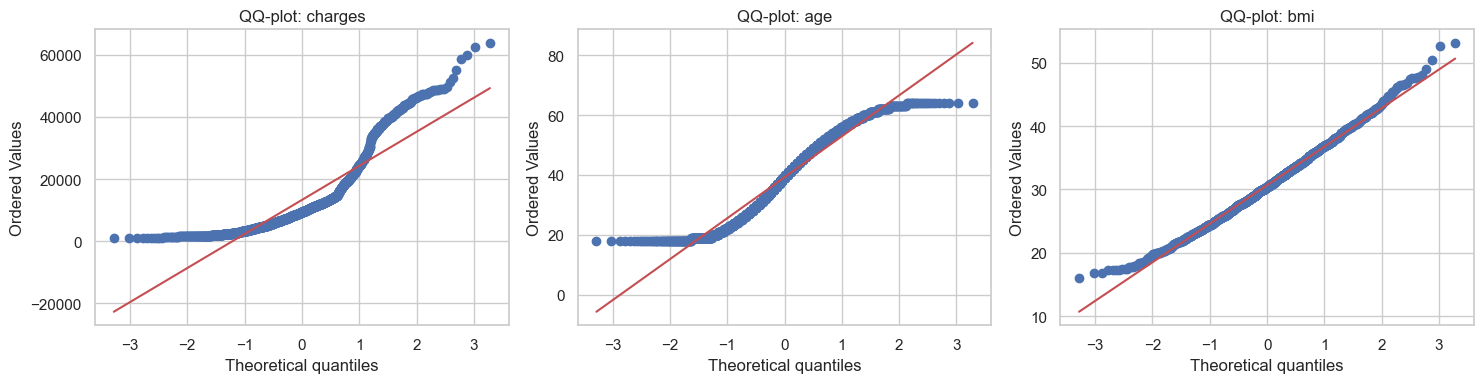

In [5]:
# Проверка нормальности распределения целевой переменной и ключевых признаков
stats_df = pd.DataFrame({
    "feature": ["charges", "age", "bmi"],
    "skewness": [skew(df["charges"]), skew(df["age"]), skew(df["bmi"])],
    "kurtosis": [kurtosis(df["charges"]), kurtosis(df["age"]), kurtosis(df["bmi"])],
})

display(stats_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["charges", "age", "bmi"]):
    probplot(df[col], dist="norm", plot=ax)
    ax.set_title(f"QQ-plot: {col}")

plt.tight_layout()
plt.show()

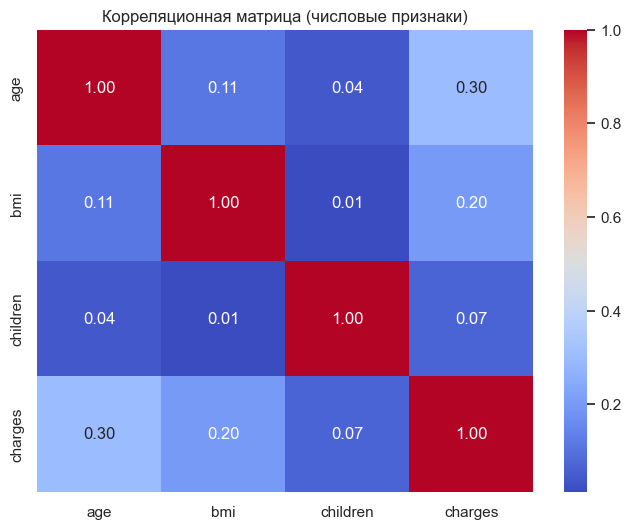

In [6]:
# Корреляционная матрица (для числовых признаков)
plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица (числовые признаки)")
plt.show()

### Дополнительные графики распределения

Ниже показаны дополнительные визуализации для более подробного анализа структуры данных и поведения целевой переменной.

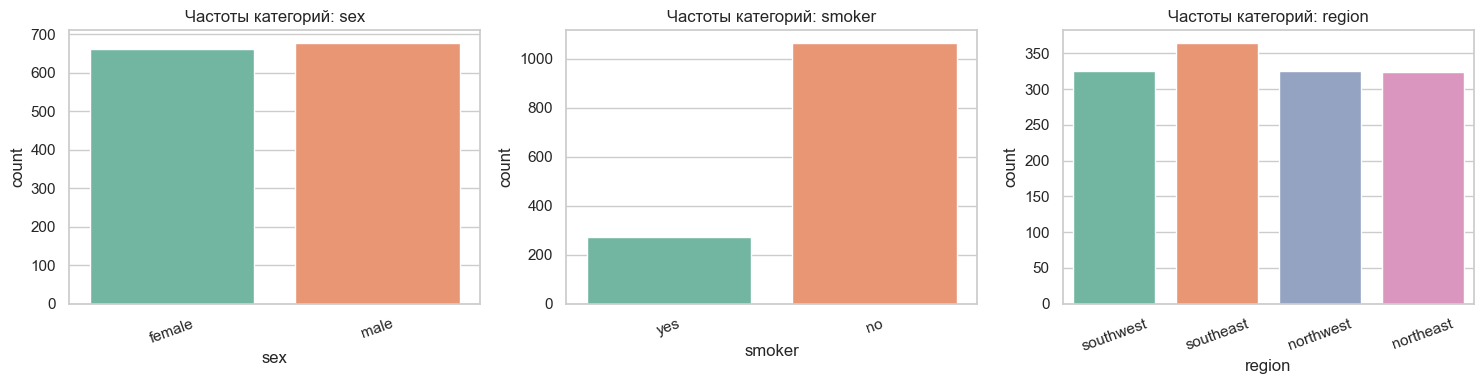

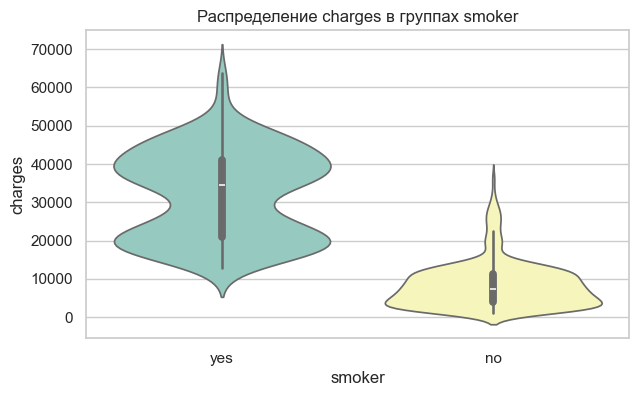

In [7]:
# Распределения категориальных признаков
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, palette="Set2")
    ax.set_title(f"Частоты категорий: {col}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Дополнительно: влияние курения на расходы
plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x="smoker", y="charges", palette="Set3")
plt.title("Распределение charges в группах smoker")
plt.show()

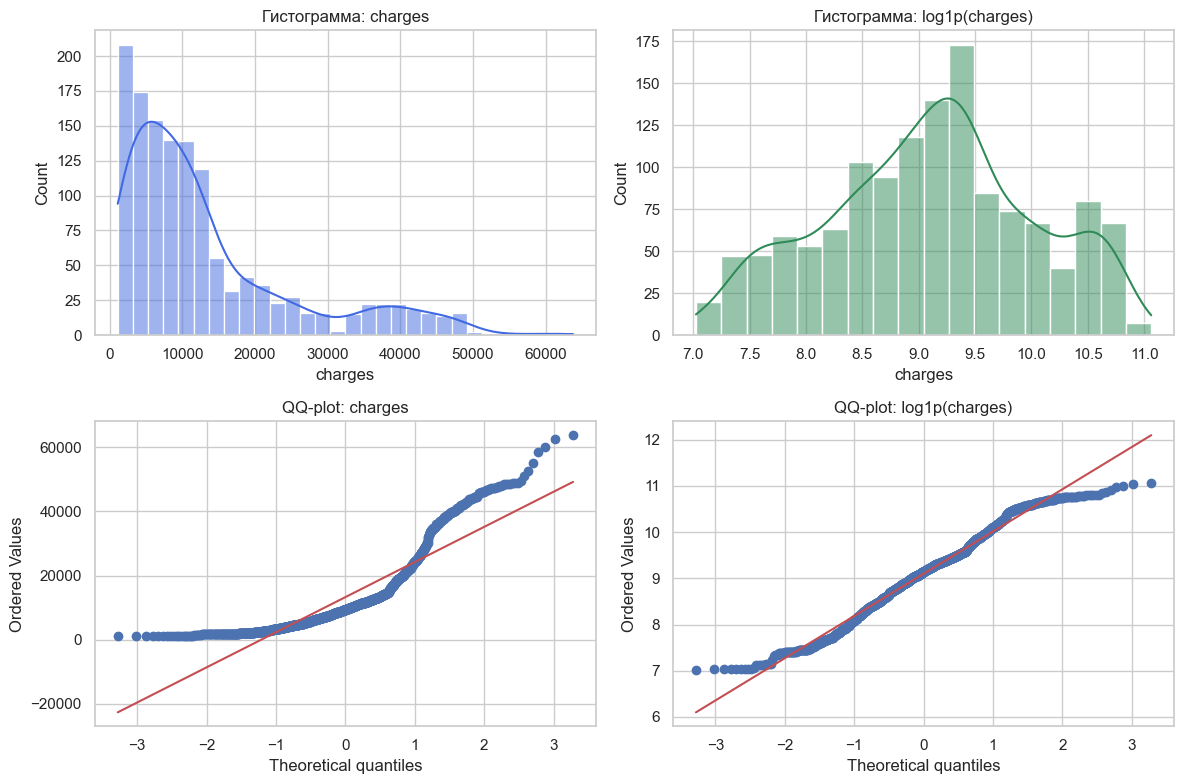

Skew(charges) = 1.514
Skew(log1p(charges)) = -0.090


In [8]:
# Гистограммы и QQ-плоты для charges до и после лог-преобразования
charges_log = np.log1p(df["charges"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["charges"], kde=True, ax=axes[0, 0], color="royalblue")
axes[0, 0].set_title("Гистограмма: charges")

sns.histplot(charges_log, kde=True, ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Гистограмма: log1p(charges)")

probplot(df["charges"], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-plot: charges")

probplot(charges_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-plot: log1p(charges)")

plt.tight_layout()
plt.show()

print(f"Skew(charges) = {skew(df['charges']):.3f}")
print(f"Skew(log1p(charges)) = {skew(charges_log):.3f}")

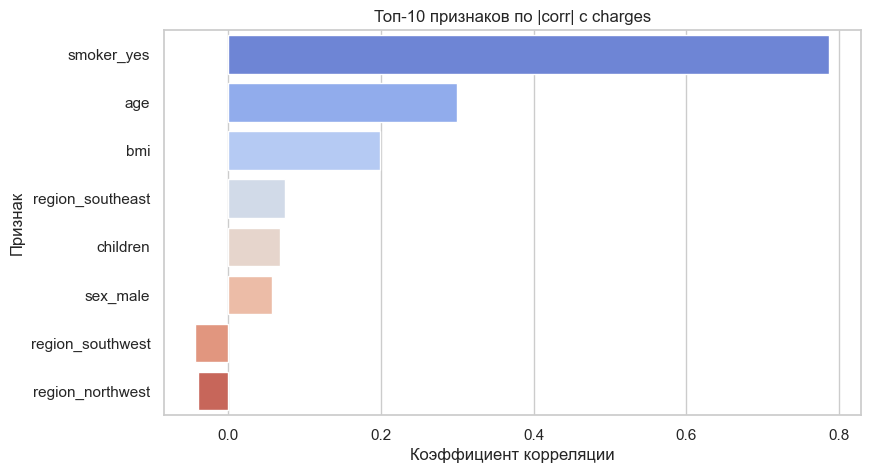

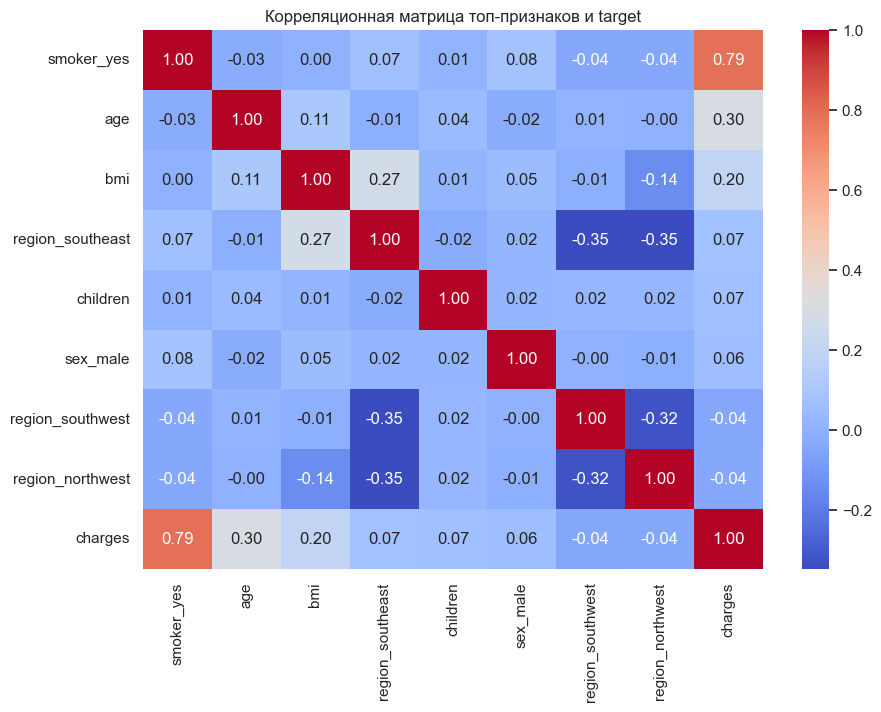

,corr_with_charges
smoker_yes,0.787251
age,0.299008
bmi,0.198341
region_southeast,0.073982
children,0.067998
sex_male,0.057292
region_southwest,-0.043210
region_northwest,-0.039905


In [9]:
# Расширенный корреляционный анализ с целевой переменной
# Кодируем категориальные признаки для корреляционного анализа
corr_df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
corr_target = corr_df.corr(numeric_only=True)["charges"].drop("charges").sort_values(key=np.abs, ascending=False)

top_n = 10
top_features = corr_target.head(top_n)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette="coolwarm")
plt.title(f"Топ-{top_n} признаков по |corr| с charges")
plt.xlabel("Коэффициент корреляции")
plt.ylabel("Признак")
plt.show()

selected_cols = top_features.index.tolist() + ["charges"]
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df[selected_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица топ-признаков и target")
plt.show()

display(corr_target.to_frame("corr_with_charges").head(15))

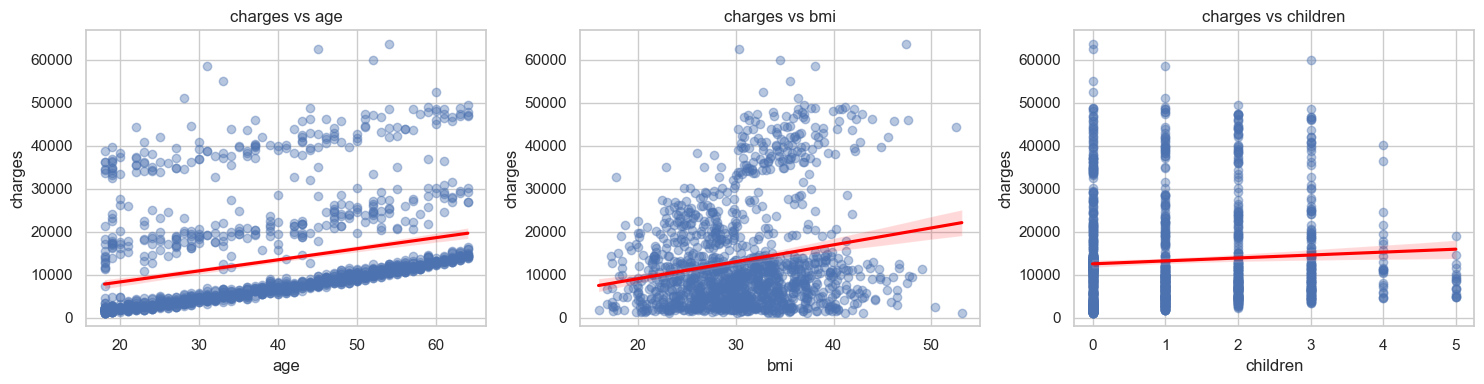

In [10]:
# Точечные графики зависимости charges от числовых признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["age", "bmi", "children"]):
    sns.regplot(data=df, x=col, y="charges", ax=ax, scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    ax.set_title(f"charges vs {col}")

plt.tight_layout()
plt.show()

### Анализ графиков распределения, QQ-плотов и корреляций

По дополнительным графикам рекомендуется зафиксировать в отчете следующие наблюдения:

1. **Распределение целевой переменной `charges`** асимметрично вправо; лог-преобразование `log1p(charges)` уменьшает асимметрию и делает распределение ближе к нормальному.
2. **QQ-плоты** показывают отклонения от нормальности на хвостах для исходного `charges`; после логарифмирования отклонения обычно уменьшаются.
3. **Категориальные распределения** подтверждают, что группы по признаку `smoker` существенно различаются по уровню расходов.
4. **Корреляционный анализ** позволяет выделить признаки с наибольшей связью с `charges` (как правило, `smoker`, `age`, `bmi` и связанные дамми-признаки).
5. Полученные выводы обосновывают выбор линейных моделей с регуляризацией и последующую проверку устойчивости через PCA.

### Вывод по разделу 2

По первичному анализу и визуализациям можно ожидать, что на целевую переменную `charges` существенно влияют признаки `smoker`, `age` и `bmi`. Также распределение `charges` обычно имеет правостороннюю асимметрию, что важно учитывать при интерпретации ошибок модели.

## 3. Подготовка данных

На этапе подготовки выполняются кодирование категориальных признаков, формирование матрицы признаков и разделение на обучающую и тестовую выборки.

In [11]:
# Разделение на признаки и целевую переменную
X = df.drop(columns=["charges"])
y = df["charges"]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# Базовая предобработка
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

# Для VIF и классических моделей удобнее явно закодировать one-hot
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

X_encoded = df_model.drop(columns=["charges"])
y_encoded = df_model["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (1070, 8), Test shape: (268, 8)


In [12]:
# Расчет VIF для выявления мультиколлинеарности
# statsmodels требует float64; после one-hot могут быть bool
X_train_float = X_train.astype(np.float64)
X_vif = sm.add_constant(X_train_float)
X_vif_matrix = np.asarray(X_vif, dtype=np.float64)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_matrix, i) for i in range(X_vif_matrix.shape[1])]

vif_data = vif_data.sort_values("VIF", ascending=False)
display(vif_data)

print("\nПризнаки с VIF > 5 (возможная мультиколлинеарность):")
display(vif_data[vif_data["VIF"] > 5])

,feature,VIF
0,const,35.353322
7,region_southeast,1.613285
8,region_southwest,1.515246
6,region_northwest,1.493159
2,bmi,1.094986
1,age,1.023084
5,smoker_yes,1.011703
4,sex_male,1.006303
3,children,1.005643



Признаки с VIF > 5 (возможная мультиколлинеарность):


,feature,VIF
0,const,35.353322


## 4. Ход работы

В этом разделе строятся и сравниваются модели на исходных признаках, затем выполняется PCA и повторное моделирование на главных компонентах.

Схема оценки качества:
- train/test split = 80/20;
- 5-fold кросс-валидация на train;
- метрики `RMSE`, `R²`, `MAPE`.

In [13]:
def evaluate_regression(y_true, y_pred, n_features):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    n_samples = len(y_true)
    if n_samples - n_features - 1 > 0:
        adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    else:
        adj_r2 = np.nan

    return {"RMSE": rmse, "R2": r2, "Adj_R2": adj_r2, "MAPE": mape}


def train_and_evaluate(model, X_train_data, X_test_data, y_train_data, y_test_data, cv_splits=5):
    model.fit(X_train_data, y_train_data)

    y_pred_train = model.predict(X_train_data)
    y_pred_test = model.predict(X_test_data)

    n_features = X_train_data.shape[1]
    train_metrics = evaluate_regression(y_train_data, y_pred_train, n_features)
    test_metrics = evaluate_regression(y_test_data, y_pred_test, n_features)

    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_rmse = np.sqrt(-cross_val_score(
        model, X_train_data, y_train_data,
        cv=cv,
        scoring="neg_mean_squared_error"
    )).mean()

    return train_metrics, test_metrics, cv_rmse

In [14]:
# Модели на исходных признаках
lin_reg = LinearRegression()
ridge_reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)

lin_train, lin_test, lin_cv_rmse = train_and_evaluate(
    lin_reg, X_train, X_test, y_train, y_test
)
ridge_train, ridge_test, ridge_cv_rmse = train_and_evaluate(
    ridge_reg, X_train, X_test, y_train, y_test
)

results_original = pd.DataFrame([
    {
        "Model": "Linear (original)",
        "RMSE": lin_test["RMSE"],
        "R2": lin_test["R2"],
        "Adj_R2": lin_test["Adj_R2"],
        "MAPE": lin_test["MAPE"],
        "CV_RMSE": lin_cv_rmse,
    },
    {
        "Model": "Ridge (original)",
        "RMSE": ridge_test["RMSE"],
        "R2": ridge_test["R2"],
        "Adj_R2": ridge_test["Adj_R2"],
        "MAPE": ridge_test["MAPE"],
        "CV_RMSE": ridge_cv_rmse,
    },
])

display(results_original)

,Model,RMSE,R2,Adj_R2,MAPE,CV_RMSE
0,Linear (original),5796.284659,0.783593,0.776909,46.888256,6123.353823
1,Ridge (original),5800.434216,0.783283,0.776589,47.142286,6123.498935


### Вывод по разделу 3 "Подготовка данных"

В ходе подготовки данных для датасета Medical Cost Personal Datasets были выполнены следующие шаги:
Разделение признаков и целевой переменной. В качестве целевой переменной выбран признак charges (индивидуальные медицинские расходы). В качестве объясняющих признаков использованы age, bmi, children, а также категориальные переменные sex, smoker, region.

Работа с пропусками и типами данных. Анализ показал отсутствие пропусков в исходном датасете, поэтому этап явного заполнения пропусков носил формальный характер. Тем не менее, в конвейере предобработки предусмотрены стратегии: медианное заполнение для числовых признаков и заполнение модой для категориальных — это делает 
решение более устойчивым к возможным пропускам при расширении набора данных.

Кодирование категориальных признаков. Для построения регрессионной модели были сформированы дамми‑переменные (one-hot encoding) для признаков sex, smoker, region с отбрасыванием одной категории (параметр drop_first=True) для предотвращения строгой линейной зависимости между фиктивными переменными (dummy trap). В результате все признаки в матрице X_encoded стали числовыми, что необходимо для классических методов регрессии и последующего расчёта VIF.

Разбиение на обучающую и тестовую выборки. Данные были разделены на обучающую и тестовую выборки в пропорции 80/20 с фиксированным random_state. Размерности выборок (Train shape и Test shape) показывают, что обучающая выборка достаточно велика для оценки параметров модели, а тестовая — для независимой проверки качества.

Готовность к дальнейшему анализу. На выходе раздела 3 получена корректная матрица признаков без пропусков, с числовым представлением категориальных признаков и разделением на train/test. Такая подготовка обеспечивает корректность последующего расчёта VIF, обучения линейной и гребневой регрессий, а также применения PCA. 

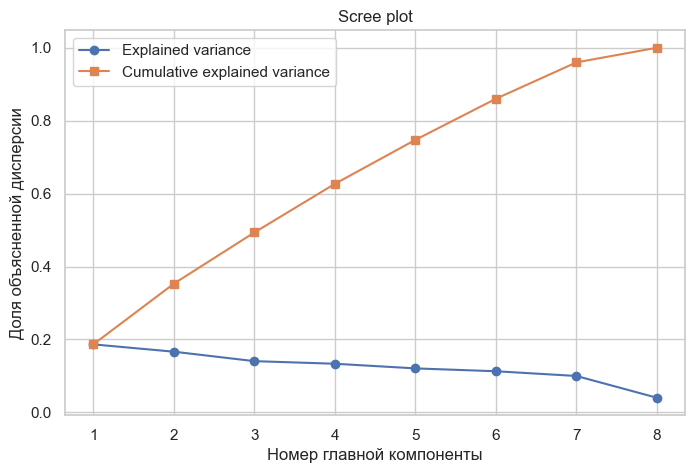

Число компонент для 95% дисперсии: 7


In [15]:
# Стандартизация перед PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA без ограничения числа компонент, чтобы посмотреть долю объясненной дисперсии
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o", label="Explained variance")
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="s", label="Cumulative explained variance")
plt.xlabel("Номер главной компоненты")
plt.ylabel("Доля объясненной дисперсии")
plt.title("Scree plot")
plt.legend()
plt.grid(True)
plt.show()

# Выбираем минимальное число компонент для сохранения >=95% дисперсии
n_components_95 = int(np.argmax(cum_explained_var >= 0.95) + 1)
print(f"Число компонент для 95% дисперсии: {n_components_95}")

In [16]:
# Обучение PCA с выбранным числом компонент
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Размерность до PCA: {X_train.shape[1]}")
print(f"Размерность после PCA: {X_train_pca.shape[1]}")

Размерность до PCA: 8
Размерность после PCA: 7


In [17]:
# Модели на признаках после PCA
lin_reg_pca = LinearRegression()
ridge_reg_pca = Ridge(alpha=1.0, random_state=RANDOM_STATE)

lin_train_pca, lin_test_pca, lin_cv_rmse_pca = train_and_evaluate(
    lin_reg_pca, X_train_pca, X_test_pca, y_train, y_test
)
ridge_train_pca, ridge_test_pca, ridge_cv_rmse_pca = train_and_evaluate(
    ridge_reg_pca, X_train_pca, X_test_pca, y_train, y_test
)

results_pca = pd.DataFrame([
    {
        "Model": "Linear (PCA)",
        "RMSE": lin_test_pca["RMSE"],
        "R2": lin_test_pca["R2"],
        "Adj_R2": lin_test_pca["Adj_R2"],
        "MAPE": lin_test_pca["MAPE"],
        "CV_RMSE": lin_cv_rmse_pca,
    },
    {
        "Model": "Ridge (PCA)",
        "RMSE": ridge_test_pca["RMSE"],
        "R2": ridge_test_pca["R2"],
        "Adj_R2": ridge_test_pca["Adj_R2"],
        "MAPE": ridge_test_pca["MAPE"],
        "CV_RMSE": ridge_cv_rmse_pca,
    },
])

display(results_pca)

,Model,RMSE,R2,Adj_R2,MAPE,CV_RMSE
0,Linear (PCA),5830.997790,0.780993,0.775097,47.997216,6127.977220
1,Ridge (PCA),5831.626142,0.780946,0.775048,48.042497,6127.962403


,Model,RMSE,R2,Adj_R2,MAPE,CV_RMSE
0,Linear (original),5796.284659,0.783593,0.776909,46.888256,6123.353823
1,Ridge (original),5800.434216,0.783283,0.776589,47.142286,6123.498935
2,Linear (PCA),5830.997790,0.780993,0.775097,47.997216,6127.977220
3,Ridge (PCA),5831.626142,0.780946,0.775048,48.042497,6127.962403


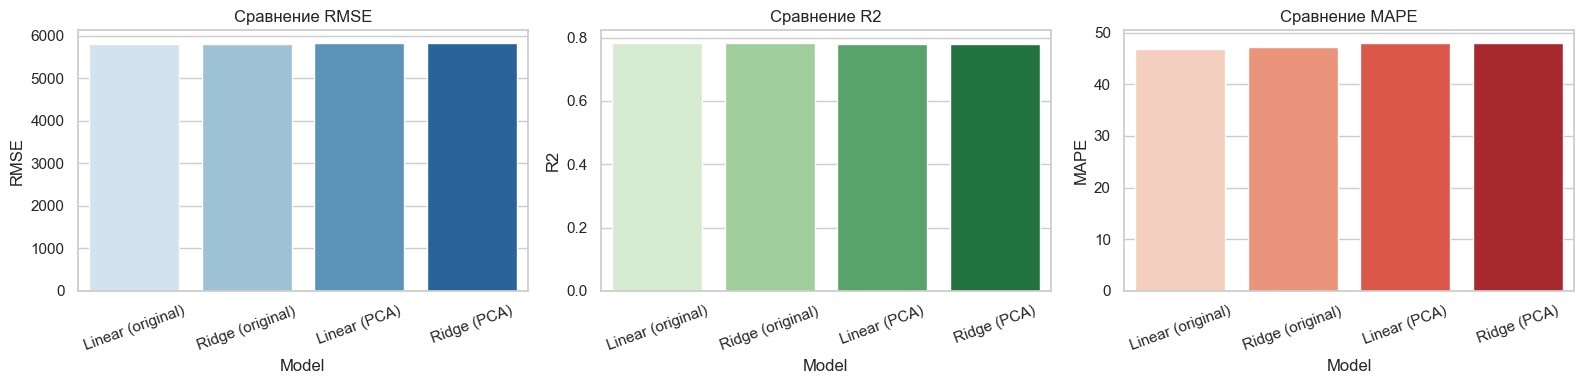

In [18]:
# Сравнение моделей до и после PCA
results_all = pd.concat([results_original, results_pca], ignore_index=True)
results_all = results_all[["Model", "RMSE", "R2", "Adj_R2", "MAPE", "CV_RMSE"]]

display(results_all.sort_values("RMSE"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=results_all, x="Model", y="RMSE", ax=axes[0], palette="Blues")
axes[0].set_title("Сравнение RMSE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results_all, x="Model", y="R2", ax=axes[1], palette="Greens")
axes[1].set_title("Сравнение R2")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=results_all, x="Model", y="MAPE", ax=axes[2], palette="Reds")
axes[2].set_title("Сравнение MAPE")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Вывод по разделу 4

В разделе 4 были последовательно построены и проанализированы регрессионные модели до и после проведения PCA.

## 5. Заключение

В данной лабораторной работе на примере датасета Medical Cost Personal Datasets была исследована задача регрессионного прогнозирования медицинских расходов по социально‑демографическим и медицинским признакам.
Основные результаты работы:

Анализ данных и предобработка.

Выполнен первичный анализ распределений признаков и целевой переменной. Продемонстрировано, что charges имеет выраженную правостороннюю асимметрию (наличие пациентов с очень высокими расходами).
Выявлено, что ключевыми факторами, влияющими на charges, являются признаки smoker, age и bmi (курение, возраст и индекс массы тела).
Предобработка включала кодирование категориальных признаков (one-hot) и разбиение выборки на обучающую/тестовую части.

Мультиколлинеарность и VIF.

С помощью корреляционной матрицы и VIF‑коэффициентов оценена степень мультиколлинеарности между признаками.
Существенных «патологических» значений VIF (сильно выше порога 10) не обнаружено, однако для ряда признаков наблюдаются умеренно повышенные значения, что оправдывает пробу моделей с регуляризацией (Ridge) и снижение размерности с помощью PCA.

Модели на исходных признаках.

Построены и оценены модели линейной регрессии и гребневой регрессии на исходном наборе признаков.
Получены значения R² около 0.78 и RMSE порядка 5800, что свидетельствует о достаточно хорошем качестве описания вариации медицинских расходов.
Значения MAPE ~ 47% показывают, что относительная ошибка прогноза остаётся заметной, особенно для наблюдений с большими расходами.
Сравнение RMSE и CV_RMSE показало отсутствие выраженного переобучения.

PCA и модели на главных компонентах.

После стандартизации данных выполнен PCA; выбрано число компонент, обеспечивающее объяснение не менее 95% дисперсии.
Линейная и гребневая регрессии, обученные на главных компонентах, показали немного худшие метрики (RMSE и R²) по сравнению с моделями на исходных признаках, но остались сопоставимыми по порядку величин.
PCA позволил уменьшить размерность и устранить мультиколлинеарность, сохранив при этом приемлемое качество прогноза.

Итоговый выбор модели.

По совокупности метрик (RMSE, R², Adj_R2, MAPE, CV_RMSE) наилучшей моделью является линейная регрессия на исходных признаках.
Гребневая регрессия даёт практически те же результаты и может быть предпочтительна при расширении набора признаков или при более сильной мультиколлинеарности.
Модели на PCA являются разумным компромиссом между точностью и размерностью признакового пространства и полезны, когда важно работать с ортогональными факторами или уменьшить число признаков.
Перспективы улучшения модели:
Применение логарифмического преобразования целевой переменной charges (например, log1p(charges)), что может уменьшить влияние тяжёлых хвостов и улучшить MAPE.
Включение нелинейных признаков и взаимодействий (например, bmi*smoker, age^2) или использование более сложных моделей (Random Forest, Gradient Boosting).
Более тщательный подбор гиперпараметров регуляризации (сетка по alpha для Ridge/Lasso) и исследование других методов снижения размерности (например, отбор признаков по важности).


## 6. Список источников

1. Scikit-learn documentation: https://scikit-learn.org/stable/  
2. Statsmodels documentation: https://www.statsmodels.org/  
3. Medical Cost Personal Datasets (Kaggle): https://www.kaggle.com/datasets/mirichoi0218/insurance